In [15]:
from pathlib import Path
import torch.nn as nn
from torch.utils.data import Dataset, ConcatDataset
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import random
import torch

from lpips import LPIPS
import time

In [16]:
class TrainImageDataset(Dataset):
    def __init__(self, image_dir) -> None:
        self.image_dir = Path(image_dir)
        self.GT_PATH = self.image_dir / 'GT'  # Assuming GT images are in a subdirectory named 'GT'
        self.NoisyLR_PATH = self.image_dir / 'NoisyLR'  # Assuming NoisyLR images are in a subdirectory named 'NoisyLR'
        self.GT_image_paths = list(self.GT_PATH.glob('*.npy'))  # Assuming images are in .npy format
        self.NoisyLR_image_paths = list(self.NoisyLR_PATH.glob('*.npy'))  # Assuming images are in .npy format
        assert len(self.GT_image_paths) == len(self.NoisyLR_image_paths)

    def __len__(self) -> int:
        return len(self.GT_image_paths)

    def __getitem__(self, idx) -> tuple[np.ndarray, np.ndarray]:
        GT_image = np.load(self.GT_image_paths[idx])  # Load the GT image
        NoisyLR_image = np.load(self.NoisyLR_image_paths[idx])  # Load the NoisyLR image
        return NoisyLR_image, GT_image  # Return both images

    def refresh(self) -> None:
        self.GT_image_paths = list(self.GT_PATH.glob('*.npy'))
        self.NoisyLR_image_paths = list(self.NoisyLR_PATH.glob('*.npy'))
        assert len(self.GT_image_paths) == len(self.NoisyLR_image_paths)


class UpscaleDataset(Dataset):
    def __init__(self, image_dir) -> None:
        self.train_dataset = TrainImageDataset(image_dir)

    def __len__(self) -> int:
        return len(self.train_dataset)

    def __getitem__(self, idx) -> tuple[np.ndarray, np.ndarray]:
        NoisyLR_image, GT_image = self.train_dataset[idx]
        # Return downscaled GT and GT image
        downscaled_image = zoom(GT_image, 0.5, order=3)
        return downscaled_image, GT_image  # Return both images

In [17]:
original_dataset = UpscaleDataset(image_dir="../data/train/train")
augmented_dataset = UpscaleDataset(image_dir="../data/train/augmented_new_noise")

dataset = ConcatDataset([original_dataset, augmented_dataset])

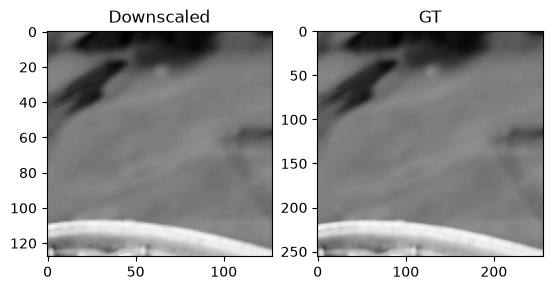

In [18]:
i = random.randint(0, len(dataset) - 1)

plt.subplot(1, 2, 1)
plt.imshow(dataset[i][0], cmap='gray')  # Display the first NoisyLR image
plt.title("Downscaled")

plt.subplot(1, 2, 2)
plt.imshow(dataset[i][1], cmap='gray')  # Display the first HighRes image
plt.title("GT")
plt.show()

In [19]:
lpips = LPIPS(net='alex')

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/vivaan/workingfolder/college/epoch/kla_hackathon/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/vivaan/workingfolder/college/epoch/kla_hackathon/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/vivaan/workingfolder/college/epoch/kla_hackathon/.venv/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


0.038969434797763824


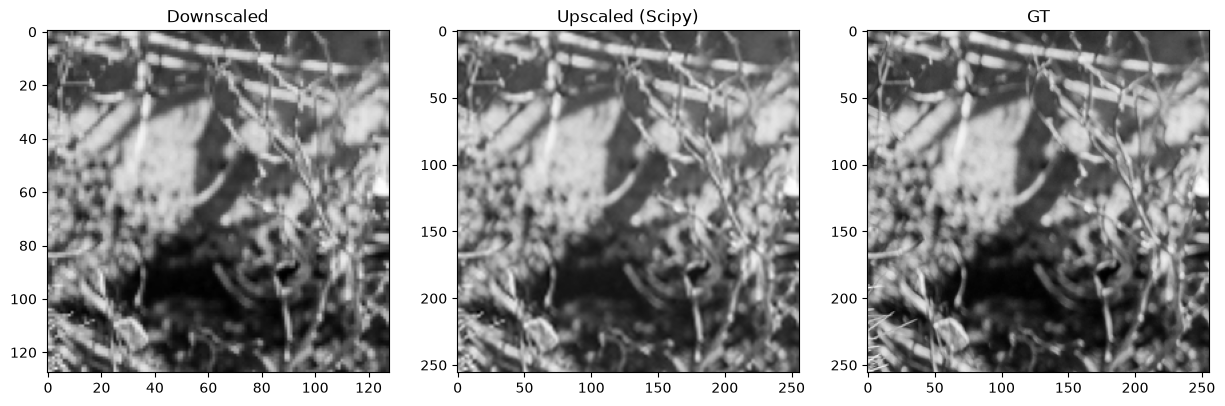

In [20]:
i = random.randint(0, len(original_dataset) - 1)
i = 2937
# scipy upscaling
downscaled_image, GT_image = original_dataset[i]
upscaled_image = zoom(downscaled_image, 2, order=3)  #

# Display the images
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(downscaled_image, cmap='gray')
axes[0].set_title("Downscaled")

axes[1].imshow(upscaled_image, cmap='gray')
axes[1].set_title("Upscaled (Scipy)")

axes[2].imshow(GT_image, cmap='gray')
axes[2].set_title("GT")

print(lpips(torch.tensor(upscaled_image).unsqueeze(0).unsqueeze(0).float(), torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()).item())
plt.show()

In [21]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'xpu' if torch.xpu.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [22]:
print(downscaled_image)
print(GT_image)

[[0.7130488  0.49864486 0.26191887 ... 0.47744435 0.4310803  0.38190407]
 [0.6664561  0.46303648 0.34681135 ... 0.44706714 0.38543049 0.37003767]
 [0.4821257  0.38944358 0.32644212 ... 0.37015375 0.32466182 0.31560126]
 ...
 [0.59886545 0.6802114  0.5918738  ... 0.2705227  0.25643402 0.22600405]
 [0.71332276 0.5231827  0.72207195 ... 0.20407923 0.18307287 0.20356214]
 [0.88380444 0.80142033 0.49500552 ... 0.15023118 0.13486497 0.19585548]]
[[0.7130488  0.6026059  0.4995211  ... 0.431002   0.41544488 0.38190407]
 [0.70034444 0.5958878  0.48912486 ... 0.41961023 0.39293018 0.37362874]
 [0.66675544 0.5488138  0.463792   ... 0.38562596 0.37249172 0.37016863]
 ...
 [0.71518725 0.7019671  0.5255916  ... 0.18292825 0.1957134  0.20344543]
 [0.9416053  0.905001   0.9158178  ... 0.15476239 0.17413788 0.18971771]
 [0.88380444 0.81963867 0.8015633  ... 0.1348668  0.15433955 0.19585548]]


Real-ESRGAN model loaded successfully.
LPIPS:  0.10736828297376633
SSIM:  0.14875340461730957
PSNR:  23.277788162231445
Time taken: 0.04 seconds


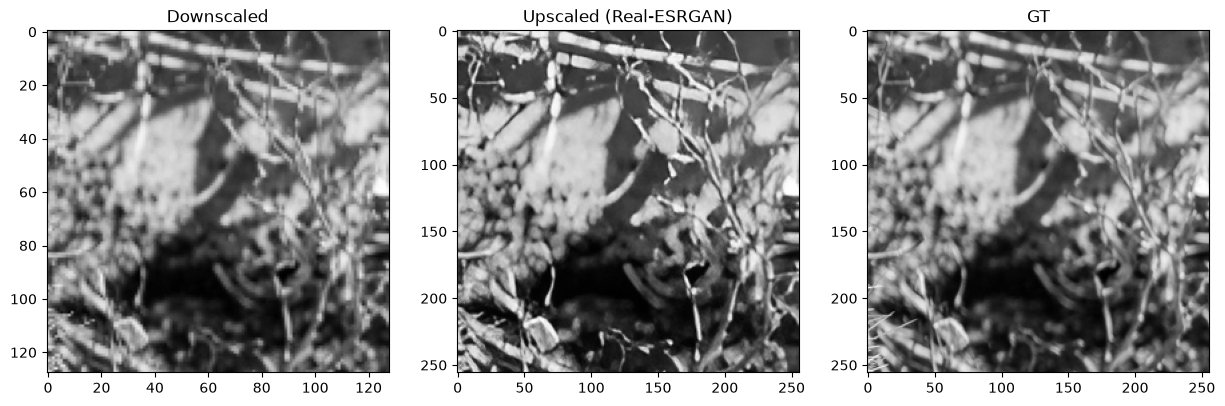

In [23]:
import torch
from pytorch_msssim import SSIM

import sys
import os
sys.path.append(os.path.abspath('..'))
from inference.realesrgan import build_real_esrgan

ssim = SSIM(data_range=1.0, size_average=True, channel=1).to(DEVICE)

# Initialize the upsampler — this downloads weights automatically on first run
upsampler = build_real_esrgan(model_path='../models/RealESRGAN_x2plus.pth', scale=2)
time_start = time.time()
img_uint8 = (downscaled_image * 255).clip(0, 255).astype(np.uint8)
RGB_downscaled_image = np.stack([img_uint8]*3, axis=-1)
output_realesrgan = upsampler.predict(RGB_downscaled_image)
output_realesrgan = np.mean(output_realesrgan, axis=-1)  # Convert to grayscale by averaging the color channels
time_end = time.time()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(downscaled_image, cmap='gray')
axes[0].set_title("Downscaled")

axes[1].imshow(output_realesrgan, cmap='gray')
axes[1].set_title("Upscaled (Real-ESRGAN)")

axes[2].imshow(GT_image, cmap='gray')
axes[2].set_title("GT")

print("LPIPS: ", lpips(torch.tensor(output_realesrgan).unsqueeze(0).float() / 255.0, torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()).item())
print("SSIM: ", 1 - ssim(torch.tensor(output_realesrgan).unsqueeze(0).unsqueeze(0).float() / 255.0, torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()).item())
print("PSNR: ", 10 * torch.log10(1 / torch.mean((torch.tensor(output_realesrgan).unsqueeze(0).unsqueeze(0).float() / 255.0 - torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()) ** 2)).item())
print(f"Time taken: {time_end - time_start:.2f} seconds")
plt.show()

In [24]:

# #generate averages over the entire dataset for lpips, ssim, psnr and time taken for upscaling

# avg_lpips = 0
# avg_psnr = 0
# avg_ssim = 0
# avg_time = 0
# upsampler = build_real_esrgan(model_path='../models/RealESRGAN_x2plus.pth', scale=2)

# for i in range(len(original_dataset)):
#     downscaled_image, GT_image = original_dataset[i]
    
#     # Initialize the upsampler — this downloads weights automatically on first run
#     time_start = time.time()
#     img_uint8 = (downscaled_image * 255).clip(0, 255).astype(np.uint8)
#     RGB_downscaled_image = np.stack([img_uint8]*3, axis=-1)
#     output_realesrgan = upsampler.predict(RGB_downscaled_image)
#     output_realesrgan = np.mean(output_realesrgan, axis=-1)  # Convert to grayscale by averaging the color channels
#     time_end = time.time()

#     avg_lpips += lpips(torch.tensor(output_realesrgan).unsqueeze(0).float() / 255.0, torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()).item()
#     avg_ssim += 1 - ssim(torch.tensor(output_realesrgan).unsqueeze(0).unsqueeze(0).float() / 255.0, torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()).item()
#     avg_psnr += 10 * torch.log10(1 / torch.mean((torch.tensor(output_realesrgan).unsqueeze(0).unsqueeze(0).float() / 255.0 - torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()) ** 2)).item()
#     avg_time += (time_end - time_start)

# avg_lpips /= len(original_dataset)
# avg_psnr /= len(original_dataset)   
# avg_ssim /= len(original_dataset)
# avg_time /= len(original_dataset)

# print("Average PSNR: ", avg_psnr)
# print("Average SSIM: ", avg_ssim)
# print("Average LPIPS: ", avg_lpips)
# print("Average time taken for upscaling:", avg_time, "seconds")

BSRGAN x2 model loaded successfully
LPIPS:  0.04921367019414902
SSIM:  0.07066577672958374
Time taken: 0.07 seconds


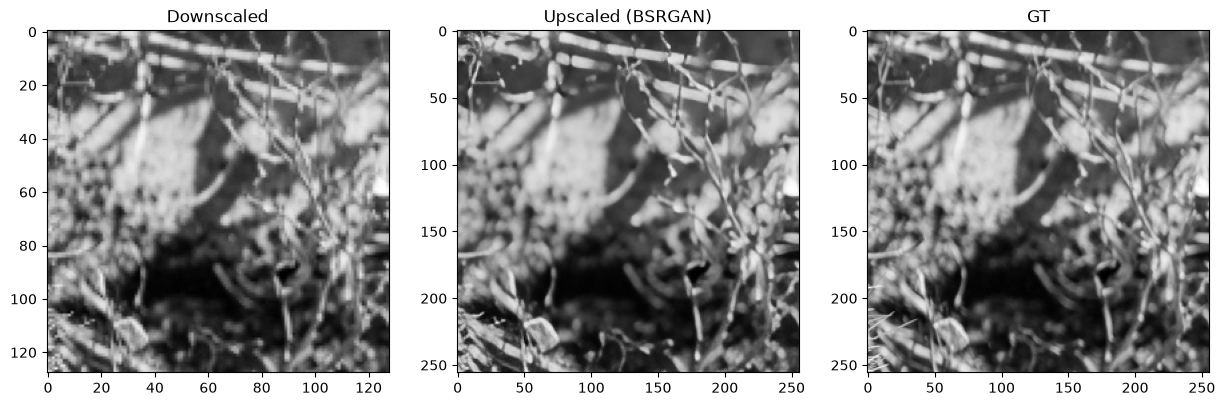

In [25]:
from upscaler_models.bsrgan import RRDBNet

BSRGAN = RRDBNet(in_nc=3, out_nc=3, nf=64, nb=23, gc=32, sf=2)  # sf=2 for x2
state_dict = torch.load('upscaler_models/weights/BSRGANx2.pth', map_location=DEVICE)
BSRGAN.load_state_dict(state_dict, strict=True)
BSRGAN.eval()
BSRGAN = BSRGAN.to(DEVICE)

print("BSRGAN x2 model loaded successfully")

with torch.no_grad():
    time_start = time.time()
    input_tensor = (torch.from_numpy(RGB_downscaled_image).float() / 255.0).unsqueeze(0).to(DEVICE).permute(0, 3, 1, 2)  # Convert to NCHW format
    output_bsrgan = BSRGAN(input_tensor)
    output_bsrgan = output_bsrgan.squeeze(0).permute(1, 2, 0).cpu().numpy()  # Convert back to HWC format
    output_bsrgan = np.mean(output_bsrgan, axis=-1)  # Convert to grayscale by averaging the color channels
    time_end = time.time()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(downscaled_image, cmap='gray')
axes[0].set_title("Downscaled")

axes[1].imshow(output_bsrgan, cmap='gray')
axes[1].set_title("Upscaled (BSRGAN)")

axes[2].imshow(GT_image, cmap='gray')
axes[2].set_title("GT")

print("LPIPS: ", lpips(torch.tensor(output_bsrgan).unsqueeze(0).float(), torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()).item())
print("SSIM: ", 1 - ssim(torch.tensor(output_bsrgan).unsqueeze(0).unsqueeze(0).float(), torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()).item())
print(f"Time taken: {time_end - time_start:.2f} seconds")
plt.show()

LPIPS:  0.05048514902591705
SSIM:  0.0649557113647461
Time taken: 0.00 seconds


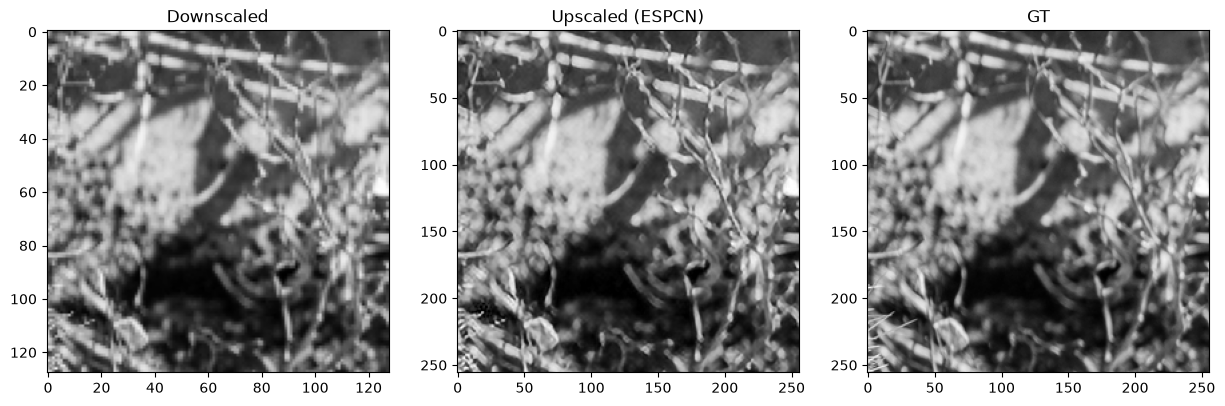

In [26]:
from upscaler_models.espcn import ESPCN, load_state_dict

espcn_model = ESPCN(upscale_factor=2, in_channels=1, out_channels=1, channels=64).to(DEVICE)
load_state_dict(espcn_model, 'upscaler_models/weights/ESPCN_x2-T91-da809cd7.pth.tar')
espcn_model.eval()

espcn_model = espcn_model.to(DEVICE)
time_start = time.time()
with torch.no_grad():
    input_tensor = (torch.from_numpy(img_uint8).float() / 255.0).unsqueeze(0).unsqueeze(0).to(DEVICE)  # Convert to NCHW format
    output_espcn = espcn_model(input_tensor)
    output_espcn = output_espcn.squeeze(0).permute(1, 2, 0).cpu().numpy()  # Convert back to HWC format
    output_espcn = np.mean(output_espcn, axis=-1)  # Convert to grayscale by averaging the color channels
    time_end = time.time()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(downscaled_image, cmap='gray')
axes[0].set_title("Downscaled")

axes[1].imshow(output_espcn, cmap='gray')
axes[1].set_title("Upscaled (ESPCN)")

axes[2].imshow(GT_image, cmap='gray')
axes[2].set_title("GT")

print("LPIPS: ", lpips(torch.tensor(output_espcn).unsqueeze(0).float(), torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()).item())
print("SSIM: ", 1 - ssim(torch.tensor(output_espcn).unsqueeze(0).unsqueeze(0).float(), torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()).item())
print(f"Time taken: {time_end - time_start:.2f} seconds")
plt.show()

SwinIR x2 model loaded successfully
Time taken: 0.11 seconds
LPIPS:  0.06426980346441269
SSIM:  0.06453782320022583


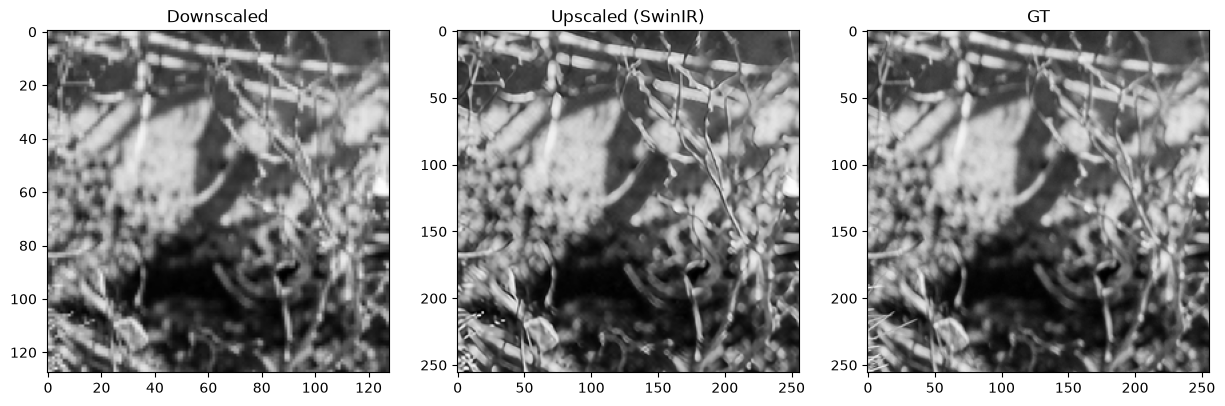

In [27]:
from upscaler_models.swinir import SwinIR

swinir_model = SwinIR(
    upscale=2,
    in_chans=3,
    img_size=64,
    window_size=8,
    img_range=1., depths=[6, 6, 6, 6, 6, 6], embed_dim=180,
    num_heads=[6, 6, 6, 6, 6, 6], mlp_ratio=2,
    upsampler='pixelshuffle', resi_connection='1conv'
)

pretrained = torch.load('upscaler_models/weights/001_classicalSR_DF2K_s64w8_SwinIR-M_x2.pth', map_location=DEVICE)
state_dict = pretrained.get('params_ema', pretrained.get('params', pretrained))
swinir_model.load_state_dict(state_dict, strict=True)
swinir_model.eval()
swinir_model = swinir_model.to(DEVICE)

print("SwinIR x2 model loaded successfully")

window_size = 8
scale = 2

time_start = time.time()
with torch.no_grad():
    input_tensor = (torch.from_numpy(RGB_downscaled_image).float() / 255.0).unsqueeze(0).to(DEVICE).permute(0, 3, 1, 2)

    # Pad H, W to multiples of window_size
    _, _, h, w = input_tensor.shape
    pad_h = (window_size - h % window_size) % window_size
    pad_w = (window_size - w % window_size) % window_size
    input_padded = torch.nn.functional.pad(input_tensor, (0, pad_w, 0, pad_h), mode='reflect')

    output_swinir = swinir_model(input_padded.to(DEVICE))

    # Crop back to correct upscaled size
    output_swinir = output_swinir[:, :, :h * scale, :w * scale]
    output_swinir = output_swinir.squeeze(0).permute(1, 2, 0).cpu().clamp(0, 1).numpy()
    output_swinir = np.mean(output_swinir, axis=-1)  # Convert to grayscale by averaging the color channels

time_end = time.time()

print(f"Time taken: {time_end - time_start:.2f} seconds")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(downscaled_image, cmap='gray')
axes[0].set_title("Downscaled")

axes[1].imshow(output_swinir, cmap='gray')
axes[1].set_title("Upscaled (SwinIR)")

axes[2].imshow(GT_image, cmap='gray')
axes[2].set_title("GT")

print("LPIPS: ", lpips(torch.tensor(output_swinir).unsqueeze(0).unsqueeze(0).float(), torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()).item())
print("SSIM: ", 1 - ssim(torch.tensor(output_swinir).unsqueeze(0).unsqueeze(0).float(), torch.tensor(GT_image).unsqueeze(0).unsqueeze(0).float()).item())
plt.show()

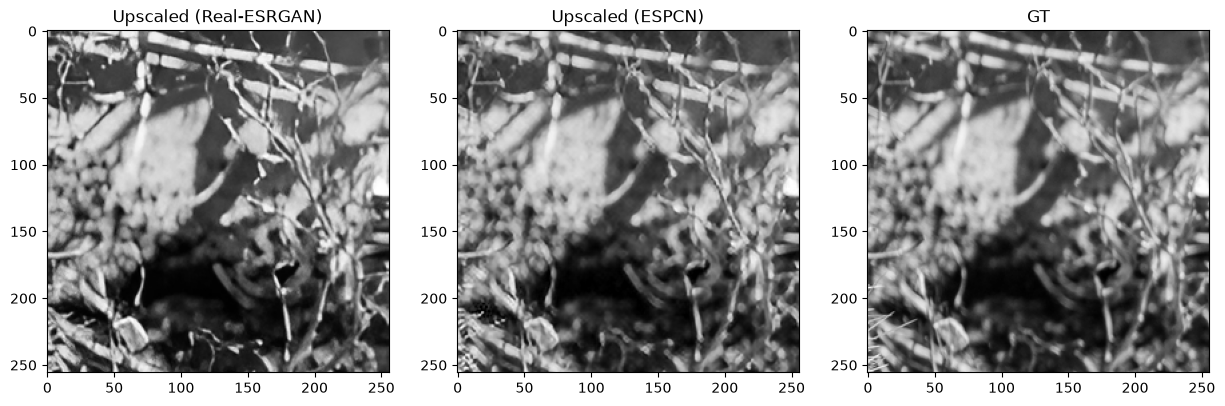

In [28]:
# Compare Real ESRGAN and ESPCN:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(output_realesrgan, cmap='gray')
axes[0].set_title("Upscaled (Real-ESRGAN)")
axes[1].imshow(output_espcn, cmap='gray')
axes[1].set_title("Upscaled (ESPCN)")
axes[2].imshow(GT_image, cmap='gray')
axes[2].set_title("GT")

plt.show()